In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

In [3]:
df = pd.read_csv("../data/samples/map_df.csv")
df_santiago = pd.read_csv("../data/raw/masters_santiago_2026_vods.csv")


In [4]:
meta_data = df_santiago.iloc[0].to_dict()

In [5]:
VALID_MAPS = {
    "ASCENT", "BIND", "SPLIT", "HAVEN", "PEARL",
    "LOTUS", "SUNSET", "ABYSS", "BREEZE", "ICEBOX", "FRACTURE", "CORRODE"
}
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df

,t_sec,current_map,ocr_text
0,0.0,NaN,NaN
1,5.0,NaN,NaN
2,10.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS
3,15.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS
4,20.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS
...,...,...,...
1180,5900.0,NaN,NaN
1181,5905.0,NaN,NaN
1182,5910.0,NaN,NaN
1183,5915.0,NaN,NaN


In [ ]:
is_valid = df["current_map"].isin(VALID_MAPS)
start_mask = (~is_valid.shift(1, fill_value=False)) & is_valid

round_start_candidates = df.loc[start_mask].copy()

round_start_candidates["round_no"] = round_start_candidates.groupby("current_map").cumcount() + 1

round_start_candidates = round_start_candidates.reset_index(drop=True)
round_start_candidates["t_min"] = round_start_candidates["t_sec"]/60
round_start_candidates

,t_sec,current_map,ocr_text,round_no,t_min
0,10.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,1,0.166667
1,110.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,2,1.833333
2,240.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,3,4.000000
3,300.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,4,5.000000
4,425.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,5,7.083333
5,545.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,6,9.083333
6,740.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,7,12.333333
7,900.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,8,15.000000
8,995.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,9,16.583333
9,1170.0,HAVEN,CURRENT: HAVEN NEXT: PEARL OECIOER: ABYSS,10,19.500000


In [51]:
gap_threshold = 1

is_valid = df["current_map"].isin(VALID_MAPS)
is_nan = df["current_map"].isna()

nan_group = (~is_nan).cumsum()
nan_streak = is_nan.groupby(nan_group).cumsum()

start_mask = (nan_streak.shift(1, fill_value=0) >= gap_threshold) & is_valid

# 最初の有効mapも開始扱いにする
first_valid_idx = is_valid.idxmax() if is_valid.any() else None
if first_valid_idx is not None:
    start_mask.loc[first_valid_idx] = True

round_start_candidates = df.loc[start_mask].copy()
round_start_candidates["round_no"] = round_start_candidates.groupby("current_map").cumcount() + 1
round_start_candidates = round_start_candidates.reset_index(drop=True)
round_start_candidates["t_min"] = round_start_candidates["t_sec"] / 60
round_start_candidates

,t_sec,current_map,ocr_text,round_no,t_min
0,10.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,1,0.166667
1,110.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,2,1.833333
2,240.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,3,4.000000
3,300.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,4,5.000000
4,425.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,5,7.083333
5,545.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,6,9.083333
6,740.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,7,12.333333
7,900.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,8,15.000000
8,995.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,9,16.583333
9,1170.0,HAVEN,CURRENT: HAVEN NEXT: PEARL OECIOER: ABYSS,10,19.500000


In [38]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import easyocr
import re
from collections import Counter


# =========================
# OCR reader
# =========================
reader = easyocr.Reader(["en"], gpu=True)


# =========================
# Video frame extraction
# =========================
def get_frame_at_sec(video_path: str, t_sec: float):
    """
    指定秒数のフレームを BGR (cv2形式) で返す
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        cap.release()
        raise ValueError("Invalid FPS")

    frame_idx = int(round(t_sec * fps))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

    ret, frame = cap.read()
    cap.release()

    if not ret or frame is None:
        raise ValueError(f"Could not read frame at t={t_sec:.2f}s")

    return frame


# =========================
# Scoreboard crops
# =========================
def crop_score_banner(frame):
    """
    上中央のスコア帯全体を crop
    座標は相対指定。必要ならここを微調整。
    """
    h, w = frame.shape[:2]

    y1 = int(h * 0.005)
    y2 = int(h * 0.06)

    x1 = int(w * 0.31)
    x2 = int(w * 0.69)

    return frame[y1:y2, x1:x2]


def crop_left_right_scores(banner):
    """
    バナーから左右スコア部分だけ crop
    これも必要なら微調整。
    """
    h, w = banner.shape[:2]

    left_crop = banner[
        int(h * 0.12):int(h * 0.88),
        int(w * 0.25):int(w * 0.38)
    ]

    right_crop = banner[
        int(h * 0.12):int(h * 0.88),
        int(w * 0.62):int(w * 0.75)
    ]

    return left_crop, right_crop


# =========================
# Preprocessing
# =========================
def preprocess_score_crop(crop, scale=4):
    """
    OCR用前処理
    - grayscale
    - resize
    - blur
    - threshold
    """
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

    gray = cv2.resize(
        gray,
        None,
        fx=scale,
        fy=scale,
        interpolation=cv2.INTER_CUBIC
    )

    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    _, th = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)

    return th


# =========================
# OCR helpers
# =========================
def sanitize_score(x):
    """
    VALORANTスコアとしてありえる範囲だけ残す
    OT込みでも25くらいまで見ておけば十分広い
    """
    if x is None:
        return None
    if 0 <= x <= 25:
        return x
    return None


def ocr_score_crop(proc_img, reader):
    """
    数字だけOCRして int を返す
    """
    results = reader.readtext(
        proc_img,
        detail=0,
        allowlist="0123456789"
    )

    text = "".join(results).strip()
    match = re.search(r"\d+", text)

    if match:
        value = int(match.group())
        return sanitize_score(value)

    return None


def majority_vote(values):
    vals = [v for v in values if v is not None]
    if not vals:
        return None
    return Counter(vals).most_common(1)[0][0]


# =========================
# Main score reading
# =========================
def read_score_from_frame(frame, reader):
    """
    1フレームから左右スコアを読む
    """
    banner = crop_score_banner(frame)
    left_crop, right_crop = crop_left_right_scores(banner)

    left_proc = preprocess_score_crop(left_crop)
    right_proc = preprocess_score_crop(right_crop)

    left_score = ocr_score_crop(left_proc, reader)
    right_score = ocr_score_crop(right_proc, reader)

    return {
        "left_score": left_score,
        "right_score": right_score,
        "banner": banner,
        "left_crop": left_crop,
        "right_crop": right_crop,
        "left_proc": left_proc,
        "right_proc": right_proc,
    }


def read_score_at_sec(video_path, t_sec, reader):
    """
    指定秒数のフレームから左右スコアを読む
    """
    frame = get_frame_at_sec(video_path, t_sec)
    result = read_score_from_frame(frame, reader)
    result["frame"] = frame
    result["t_sec"] = t_sec
    return result


def read_score_multi_sec(video_path, t_list, reader):
    """
    複数秒数で読み、多数決で最終スコアを返す
    """
    raw_results = []
    left_scores = []
    right_scores = []

    for t_sec in t_list:
        try:
            result = read_score_at_sec(video_path, t_sec, reader)
            raw_results.append(result)
            left_scores.append(result["left_score"])
            right_scores.append(result["right_score"])
        except Exception as e:
            raw_results.append({
                "t_sec": t_sec,
                "error": str(e),
                "left_score": None,
                "right_score": None
            })
            left_scores.append(None)
            right_scores.append(None)

    return {
        "left_score": majority_vote(left_scores),
        "right_score": majority_vote(right_scores),
        "left_candidates": left_scores,
        "right_candidates": right_scores,
        "raw_results": raw_results
    }


# =========================
# Visualization
# =========================
def show_score_read_result(result):
    """
    read_score_at_sec の結果を可視化
    """
    frame = result["frame"]
    banner = result["banner"]
    left_crop = result["left_crop"]
    right_crop = result["right_crop"]
    left_proc = result["left_proc"]
    right_proc = result["right_proc"]

    print(f"t_sec      : {result['t_sec']:.2f}")
    print(f"left_score : {result['left_score']}")
    print(f"right_score: {result['right_score']}")

    fig, axes = plt.subplots(2, 3, figsize=(14, 7))

    axes[0, 0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title("frame")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(cv2.cvtColor(banner, cv2.COLOR_BGR2RGB))
    axes[0, 1].set_title("score banner")
    axes[0, 1].axis("off")

    axes[0, 2].axis("off")

    axes[1, 0].imshow(cv2.cvtColor(left_crop, cv2.COLOR_BGR2RGB))
    axes[1, 0].set_title("left score crop")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(left_proc, cmap="gray")
    axes[1, 1].set_title("left processed")
    axes[1, 1].axis("off")

    axes[1, 2].imshow(cv2.cvtColor(right_crop, cv2.COLOR_BGR2RGB))
    axes[1, 2].set_title("right score crop")
    axes[1, 2].axis("off")

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(4, 3))
    plt.imshow(right_proc, cmap="gray")
    plt.title("right processed")
    plt.axis("off")
    plt.show()


# =========================
# Convert to team_a / team_b score
# =========================
def scores_to_team_order(left_score, right_score, meta_data):
    """
    画面左が team_a, 右が team_b で固定ならそのまま返す
    必要ならここで並び替えを変える
    """
    return {
        "team_a": meta_data["team_a"],
        "team_b": meta_data["team_b"],
        "score_a": left_score,
        "score_b": right_score,
    }


# =========================
# Label generation
# =========================
def make_round_label(score_before_a, score_before_b, score_after_a, score_after_b):
    """
    team_a視点
    1 = team_aがラウンド勝ち
    0 = team_aがラウンド負け
    None = 異常値
    """
    if any(v is None for v in [score_before_a, score_before_b, score_after_a, score_after_b]):
        return None

    da = score_after_a - score_before_a
    db = score_after_b - score_before_b

    if da == 1 and db == 0:
        return 1
    elif da == 0 and db == 1:
        return 0
    else:
        return None

In [42]:
import pandas as pd
import numpy as np

def add_left_win_label(
    df,
    map_col="current_map",
    left_col="left_score",
    right_col="right_score",
    label_col="left_win_label",
    keep_helper_cols=False
):
    out = df.copy()

    out["_next_map"] = out[map_col].shift(-1)
    out["_next_left"] = out[left_col].shift(-1)
    out["_next_right"] = out[right_col].shift(-1)
    out["_map_changed"] = out[map_col] != out["_next_map"]

    def judge_row(row):
        next_left = row["_next_left"]
        next_right = row["_next_right"]

        if pd.isna(next_left) or pd.isna(next_right):
            return np.nan

        if not row["_map_changed"]:
            if next_left > row[left_col] and next_right == row[right_col]:
                return 1
            elif next_right > row[right_col] and next_left == row[left_col]:
                return 0
            else:
                return np.nan
        else:
            if next_left > next_right:
                return 1
            elif next_left < next_right:
                return 0
            else:
                return np.nan

    out[label_col] = out.apply(judge_row, axis=1)

    if not keep_helper_cols:
        out = out.drop(columns=["_next_map", "_next_left", "_next_right", "_map_changed"])

    return out

t_sec      : 4360.00
left_score : 6
right_score: 4


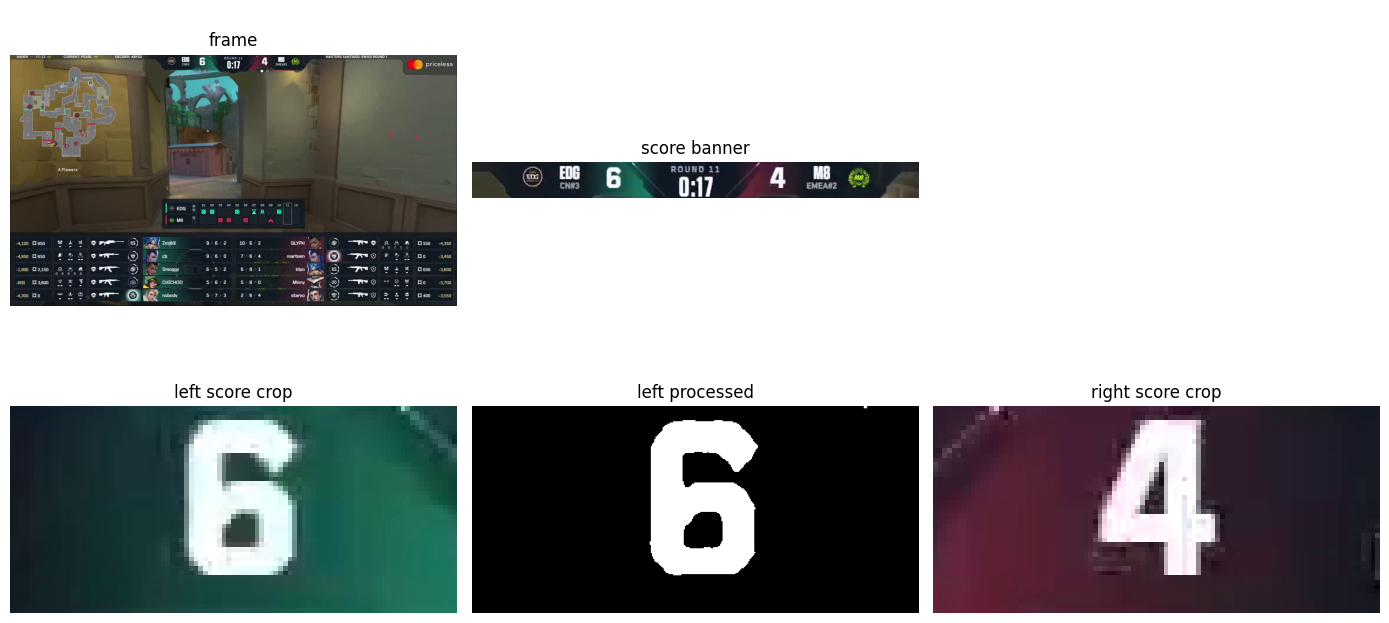

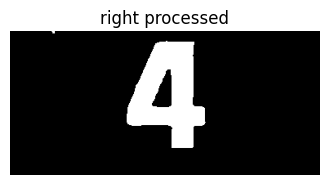

In [49]:
t_test = 4360.0	
video_path = Path("../data/vods/M8 vs. EDG - VALORANT Masters Santiago - SWISS.mp4")
result = read_score_at_sec(video_path, t_test, reader)
show_score_read_result(result)

In [44]:
left_scores = []
right_scores = []

for t in round_start_candidates["t_sec"]:
    res = read_score_multi_sec(video_path, [t,t+5,t+10], reader)
    left_scores.append(res["left_score"])
    right_scores.append(res["right_score"])

round_start_candidates["left_score"] = left_scores
round_start_candidates["right_score"] = right_scores



In [47]:
round_start_candidates = add_left_win_label(round_start_candidates)
round_start_candidates

,t_sec,current_map,ocr_text,round_no,t_min,left_score,right_score,left_win_label
0,10.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,1,0.166667,0,0,1.0
1,110.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,2,1.833333,1,0,0.0
2,240.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,3,4.000000,1,1,0.0
3,300.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,4,5.000000,1,2,1.0
4,425.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,5,7.083333,2,2,0.0
5,545.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,6,9.083333,2,3,0.0
6,740.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,7,12.333333,2,4,0.0
7,900.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,8,15.000000,2,5,0.0
8,995.0,HAVEN,CURRENT: HAVEN NEXT: PEARL DECIDER: ABYSS,9,16.583333,2,6,0.0
9,1170.0,HAVEN,CURRENT: HAVEN NEXT: PEARL OECIOER: ABYSS,10,19.500000,2,7,1.0
